In [2]:
import torchvision
from torchvision import transforms
from torch.utils.data import Subset
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt

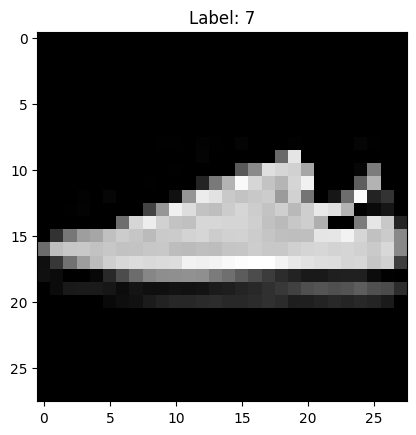

In [3]:
image_path = './'
transform = transforms.Compose([
    transforms.ToTensor()
    ])

mnist_dataset = torchvision.datasets.FashionMNIST(
    root=image_path, train=True,
    transform=transform, download=True
    )

mnist_valid_dataset = Subset(mnist_dataset, torch.arange(10000))
mnist_train_dataset = Subset(mnist_dataset, torch.arange(10000, len(mnist_dataset)))

mnist_test_dataset = torchvision.datasets.FashionMNIST(
    root=image_path, train=False,
    transform=transform, download=False
    )
 

# Show an image from the dataset
image, label = mnist_dataset[6]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [4]:
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset,
                      batch_size,
                      shuffle=True)

valid_dl = DataLoader(mnist_valid_dataset,
                      batch_size,
                      shuffle=False)

In [5]:
model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=1, out_channels=32,
        kernel_size=5, padding=2
        )
    )

model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=5, padding=2
        )
    )

model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

In [6]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

In [7]:
model.add_module('flatten', nn.Flatten())

In [8]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

In [9]:
model.add_module('fc1', nn.Linear(3136, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))
model.add_module('fc2', nn.Linear(1024, 10))
model = model.to('cuda')

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to('cuda')
            y_batch = y_batch.to('cuda')
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            loss_hist_train[epoch] += loss.item()*y_batch.size(0)

            is_correct = (
                torch.argmax(pred, dim=1) == y_batch
            ).float()
            accuracy_hist_train[epoch] += is_correct.sum()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()

        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to('cuda')
                y_batch = y_batch.to('cuda')
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += \
                    loss.item()*y_batch.size(0)
                is_correct = (
                    torch.argmax(pred, dim=1) == y_batch
                ).float()
                accuracy_hist_valid[epoch] += is_correct.sum()
        
        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Epoch {epoch+1} accuracy: '
              f'{accuracy_hist_train[epoch]:.4f} val_accuracy: '
              f'{accuracy_hist_valid[epoch]:.4f}')
        
    return loss_hist_train, loss_hist_valid, \
        accuracy_hist_train, accuracy_hist_valid

In [12]:
torch.manual_seed(1)
num_epochs = 20
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.8253 val_accuracy: 0.8838
Epoch 2 accuracy: 0.8911 val_accuracy: 0.9076
Epoch 3 accuracy: 0.9055 val_accuracy: 0.9099
Epoch 4 accuracy: 0.9176 val_accuracy: 0.9123
Epoch 5 accuracy: 0.9278 val_accuracy: 0.9217
Epoch 6 accuracy: 0.9354 val_accuracy: 0.9231
Epoch 7 accuracy: 0.9418 val_accuracy: 0.9207
Epoch 8 accuracy: 0.9499 val_accuracy: 0.9213
Epoch 9 accuracy: 0.9553 val_accuracy: 0.9207
Epoch 10 accuracy: 0.9609 val_accuracy: 0.9209
Epoch 11 accuracy: 0.9655 val_accuracy: 0.9217
Epoch 12 accuracy: 0.9683 val_accuracy: 0.9246
Epoch 13 accuracy: 0.9722 val_accuracy: 0.9217
Epoch 14 accuracy: 0.9753 val_accuracy: 0.9248
Epoch 15 accuracy: 0.9785 val_accuracy: 0.9262
Epoch 16 accuracy: 0.9788 val_accuracy: 0.9210
Epoch 17 accuracy: 0.9825 val_accuracy: 0.9224
Epoch 18 accuracy: 0.9817 val_accuracy: 0.9244
Epoch 19 accuracy: 0.9850 val_accuracy: 0.9208
Epoch 20 accuracy: 0.9861 val_accuracy: 0.9202
